# 1. Libraries

In [57]:
# Libraries for the model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import a random rf classifier
from sklearn.ensemble import RandomForestClassifier
# Import a Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 2. Loading the preprocessed data

In [50]:
# For the male model
X_train_male = pd.read_csv('../Data/Train/Xmale_train.csv').drop(columns=['Fare_scaled'])
y_train_male = pd.read_csv('../Data/Train/ymale_train.csv')
X_test_male = pd.read_csv('../Data/Test/Xmale_test.csv').drop(columns=['Fare_scaled'])
y_test_male = pd.read_csv('../Data/Test/ymale_test.csv')

In [51]:
# For the female model
X_train_fem = pd.read_csv('../Data/Train/Xfemale_train.csv').drop(columns=['Fare_scaled'])
y_train_fem = pd.read_csv('../Data/Train/yfemale_train.csv')
X_test_fem = pd.read_csv('../Data/Test/Xfemale_test.csv').drop(columns=['Fare_scaled'])
y_test_fem = pd.read_csv('../Data/Test/yfemale_test.csv')

In [66]:
# All data
df = pd.read_csv('../Data/Titanic-Dataset.csv')
df = df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex']]

We are going to use the same model for both Male and Female, but each will be trained with their corresponding sets. However, we will implement a RandomForest, but also a Logistic Regression.

# 3. T-Learner implementation (Random Forest)

## 3.1. Male model

In [53]:
# Let's do a GridSearch for the best parameters

# Define the base model
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Define the parameter grid
param_grid = {
    'n_estimators': [25, 50, 100],
    'max_depth': [5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2']
}

# Set up the GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Fit the grid search (use your training data)
grid_search.fit(X_train_male, y_train_male)

# Print the best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)



Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.8064665336477418


c:\Users\sebas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [54]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Predict on both train and test sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate metrics for the train set
    print("\nTrain Set Evaluation:")
    print(f"Accuracy: {accuracy_score(y_train, y_train_pred)}")
    print(f"Precision: {precision_score(y_train, y_train_pred, average='binary')}")
    print(f"Recall: {recall_score(y_train, y_train_pred, average='binary')}")
    print(f"F1-Score: {f1_score(y_train, y_train_pred, average='binary')}")
    print(f"ROC AUC: {roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])}")
    print("\nClassification Report:\n", classification_report(y_train, y_train_pred))

    # Plot confusion matrix for the train set
    cm_train = confusion_matrix(y_train, y_train_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.title("Confusion Matrix - Train Set")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Calculate metrics for the test set
    print("\nTest Set Evaluation:")
    print(f"Accuracy: {accuracy_score(y_test, y_test_pred)}")
    print(f"Precision: {precision_score(y_test, y_test_pred, average='binary')}")
    print(f"Recall: {recall_score(y_test, y_test_pred, average='binary')}")
    print(f"F1-Score: {f1_score(y_test, y_test_pred, average='binary')}")
    print(f"ROC AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])}")
    print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

    # Plot confusion matrix for the test set
    cm_test = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.title("Confusion Matrix - Test Set")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


Train Set Evaluation:
Accuracy: 0.8629032258064516
Precision: 0.8994082840236687
Recall: 0.8172043010752689
F1-Score: 0.856338028169014
ROC AUC: 0.9526065152040698

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87       372
           1       0.90      0.82      0.86       372

    accuracy                           0.86       744
   macro avg       0.87      0.86      0.86       744
weighted avg       0.87      0.86      0.86       744



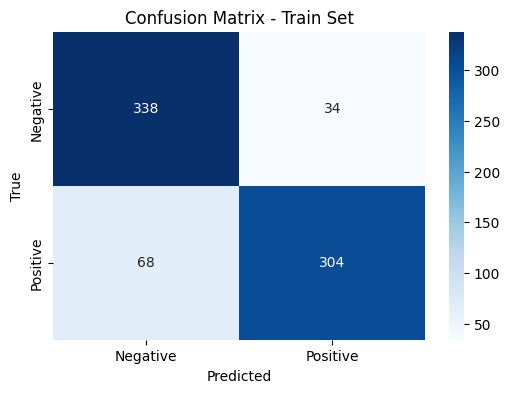


Test Set Evaluation:
Accuracy: 0.7586206896551724
Precision: 0.36666666666666664
Recall: 0.55
F1-Score: 0.44
ROC AUC: 0.6526041666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.80      0.85        96
           1       0.37      0.55      0.44        20

    accuracy                           0.76       116
   macro avg       0.63      0.68      0.64       116
weighted avg       0.80      0.76      0.78       116



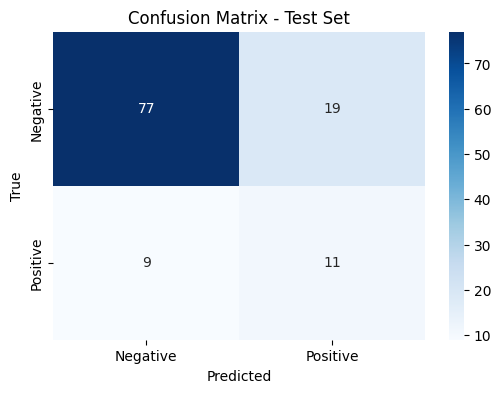

In [55]:
# Evaluate the model using the function we defined
best_rf_model = grid_search.best_estimator_
evaluate_model(best_rf_model, X_train_male, y_train_male, X_test_male, y_test_male)

## 3.2. Female model


Train Set Evaluation:
Accuracy: 0.9335106382978723
Precision: 0.9222797927461139
Recall: 0.9468085106382979
F1-Score: 0.9343832020997376
ROC AUC: 0.9894607288365777

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.93       188
           1       0.92      0.95      0.93       188

    accuracy                           0.93       376
   macro avg       0.93      0.93      0.93       376
weighted avg       0.93      0.93      0.93       376



c:\Users\sebas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


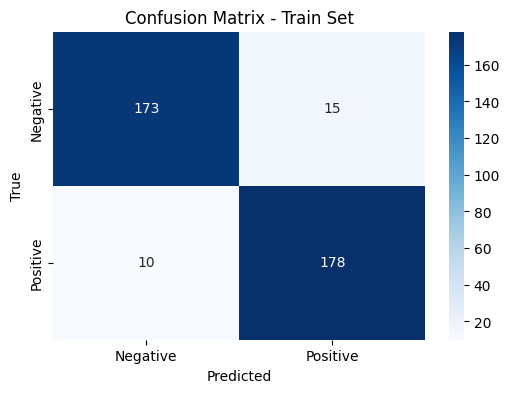


Test Set Evaluation:
Accuracy: 0.7301587301587301
Precision: 0.8333333333333334
Recall: 0.7777777777777778
F1-Score: 0.8045977011494253
ROC AUC: 0.821604938271605

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.61      0.56        18
           1       0.83      0.78      0.80        45

    accuracy                           0.73        63
   macro avg       0.68      0.69      0.68        63
weighted avg       0.74      0.73      0.74        63



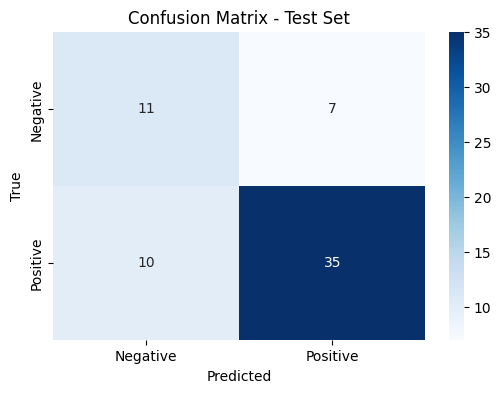

In [56]:
female_rf = RandomForestClassifier(random_state=42, class_weight='balanced', **grid_search.best_params_)
female_rf.fit(X_train_fem, y_train_fem)
evaluate_model(female_rf, X_train_fem, y_train_fem, X_test_fem, y_test_fem)

# 4. T-Learner (Logistic Regression)

## 4.1. Male model

In [58]:
# Let's do a GridSearch for the best parameters

# Define the base model
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# Define the parameter grid
param_grid = {
    'solver': ['liblinear', 'saga'],  # solvers for logistic regression
    'penalty': ['l1', 'l2'],              # regularization types
    'C': [0.01, 0.1, 1, 10]       # inverse of regularization strength
}

# Set up the GridSearchCV
grid_search = GridSearchCV(estimator=log_reg,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=2)

# Fit the grid search (use your training data)
grid_search.fit(X_train_male, y_train_male)

# Print the best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Score: 0.7311536368583349


c:\Users\sebas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Train Set Evaluation:
Accuracy: 0.7271505376344086
Precision: 0.782608695652174
Recall: 0.6290322580645161
F1-Score: 0.6974664679582713
ROC AUC: 0.7868106139438086

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.83      0.75       372
           1       0.78      0.63      0.70       372

    accuracy                           0.73       744
   macro avg       0.74      0.73      0.72       744
weighted avg       0.74      0.73      0.72       744



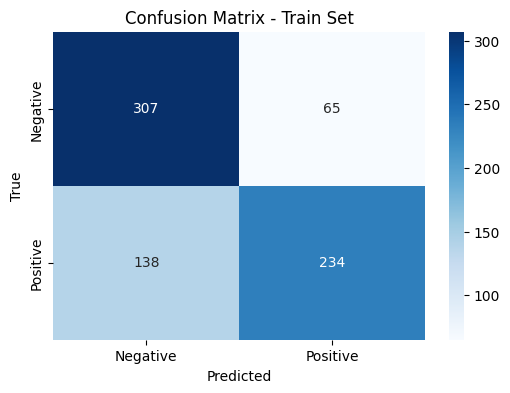


Test Set Evaluation:
Accuracy: 0.7327586206896551
Precision: 0.3333333333333333
Recall: 0.55
F1-Score: 0.41509433962264153
ROC AUC: 0.6614583333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.77      0.83        96
           1       0.33      0.55      0.42        20

    accuracy                           0.73       116
   macro avg       0.61      0.66      0.62       116
weighted avg       0.80      0.73      0.76       116



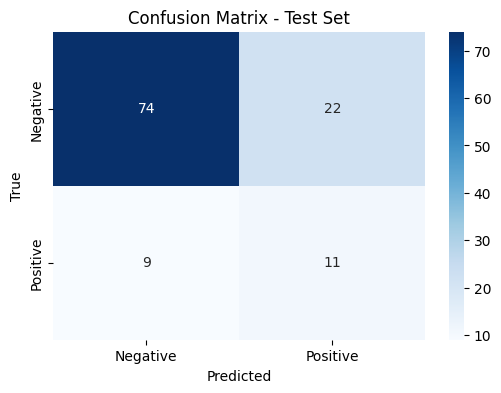

In [59]:
# Evaluate the model using the function we defined
best_log_reg = grid_search.best_estimator_
evaluate_model(best_log_reg, X_train_male, y_train_male, X_test_male, y_test_male)

## 4.2. Female model

In [60]:
log_reg_female = LogisticRegression(class_weight='balanced', 
                                    random_state=42, 
                                    max_iter=1000, 
                                    **grid_search.best_params_)

log_reg_female.fit(X_train_fem, y_train_fem)

c:\Users\sebas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')


Train Set Evaluation:
Accuracy: 0.7074468085106383
Precision: 0.7746478873239436
Recall: 0.5851063829787234
F1-Score: 0.6666666666666666
ROC AUC: 0.758728497057492

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.83      0.74       188
           1       0.77      0.59      0.67       188

    accuracy                           0.71       376
   macro avg       0.72      0.71      0.70       376
weighted avg       0.72      0.71      0.70       376



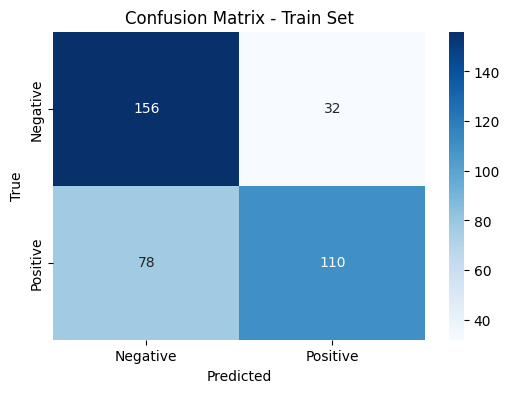


Test Set Evaluation:
Accuracy: 0.7142857142857143
Precision: 1.0
Recall: 0.6
F1-Score: 0.75
ROC AUC: 0.8543209876543211

Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67        18
           1       1.00      0.60      0.75        45

    accuracy                           0.71        63
   macro avg       0.75      0.80      0.71        63
weighted avg       0.86      0.71      0.73        63



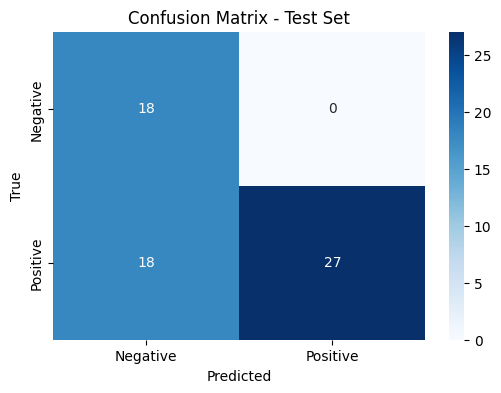

In [61]:
evaluate_model(log_reg_female, X_train_fem, y_train_fem, X_test_fem, y_test_fem)

# 5. ATE

In [67]:
df = df.dropna()
gender = df['Sex'] 

# Modelo de Random Forest
y_hat_male = best_rf_model.predict_proba(df.drop(columns=['Sex']))[:, 1]
y_hat_female = female_rf.predict_proba(df.drop(columns=['Sex']))[:, 1]

# Modelo de regresión logística
y_hat_male_lr = best_log_reg.predict_proba(df.drop(columns=['Sex']))[:, 1]
y_hat_female_lr = log_reg_female.predict_proba(df.drop(columns=['Sex']))[:, 1]

In [68]:

# Diferencia individual según género real
effect = np.where(gender == 'male',
                  y_hat_male - y_hat_female,
                  y_hat_female - y_hat_male)

In [69]:
# ATE (Average Treatment Effect)
ate = effect.mean()
print(f"ATE (average effect of gender-based models): {ate:.4f}")

ATE (average effect of gender-based models): -0.0208


In [70]:

# Diferencia individual según género real
effect = np.where(gender == 'male',
                  y_hat_male_lr - y_hat_female_lr,
                  y_hat_female_lr - y_hat_male_lr)

# ATE (Average Treatment Effect)
ate = effect.mean()
print(f"ATE (average effect of gender-based models): {ate:.4f}")

ATE (average effect of gender-based models): -0.0390


# 6. Conclusions

In this project, I set out to explore the average effect of gender on survival outcomes using the Titanic dataset. To do this, I implemented the T-Learner methodology, training separate machine learning models for men and women. The models chosen were Random Forest and Logistic Regression, and before training, I carefully preprocessed the data by imputing missing values in the Age column using an Iterative Imputer and scaling the Fare variable.

Once the models were trained, I used them to predict survival probabilities for all individuals, regardless of gender. This allowed me to estimate the individual treatment effect by comparing the predictions of the male and female models. The average of these differences gave me the ATE (Average Treatment Effect). For the Random Forest models, the ATE was -0.0208, and for the Logistic Regression models, it was -0.0390. These negative values indicate that, on average, the models trained on female data predict a slightly higher likelihood of survival compared to those trained on male data.

In conclusion, the results suggest that men are predicted to be approximately 2% to 4% less likely to survive than women, depending on the model used. This finding is consistent with historical survival patterns and demonstrates how even simple causal inference techniques, like the T-Learner, can reveal meaningful insights from well-known datasets.